优化方法：随机梯度下降,批量不能太小也不能太大，学习率也是


In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

features: tensor([1.1810, 1.2065]) 
label: tensor([2.4564])


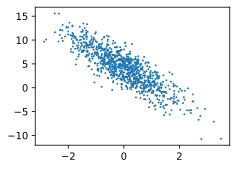

In [2]:
def synthetic_data(w, b, num_examples):  
    """生成 y = Xw + b + 噪声。"""
    X = torch.normal(0, 1, (num_examples, len(w)))#标准正态分布
    y = torch.matmul(X, w) + b#真实标签无噪声
    y += torch.normal(0, 0.01, y.shape)#添加均值0标准差0.01高斯噪声
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)#生成一个数据集，1000个样本
print('features:', features[0],'\nlabel:', labels[0])
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);




In [ ]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
    
    batch_size = 10



In [7]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.0683, -1.6973],
        [-0.9452, -0.5235],
        [ 0.0522,  0.1603],
        [ 1.5902, -1.3563],
        [ 0.9314,  0.6315],
        [-0.9678,  0.4079],
        [-1.1554, -0.1821],
        [-0.5565, -0.3193],
        [ 1.4481,  0.6295],
        [-0.6855, -1.6452]]) 
 tensor([[10.1139],
        [ 4.0818],
        [ 3.7477],
        [11.9948],
        [ 3.9178],
        [ 0.8772],
        [ 2.4964],
        [ 4.1703],
        [ 4.9769],
        [ 8.4360]])


给一些样本标号

In [32]:
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

标准化w平均0偏差0.01，都grad=true

In [33]:
#定义模型
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

            

In [34]:
#定义损失函数
def squared_loss(y_hat, y):
    """均方损失 y_hat是预测值，y是真实值"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2



In [35]:
#定义优化算法
def sgd(params, lr, batch_size):
    """小批量随机梯度下降 给定参数学习率lr和batchsize"""
    with torch.no_grad():#更新不要参与梯度计算
        for param in params:#对于每一个参数
            param -= lr * param.grad / batch_size#更新
            param.grad.zero_()#梯度清零


lr = 0.03
num_epochs = 3


In [37]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
#每一次对数据扫一次，拿出批量大小的样本，计算损失，更新参数
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)#计算损失
        l.sum().backward()#求和之后，反向传播，计算梯度
        sgd([w, b], lr, batch_size)#更新参数
    with torch.no_grad():#计算预测和label的误差
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')





tensor([[-0.1963,  0.2432],
        [ 0.8878,  1.2005],
        [ 1.8968,  0.7943],
        [ 0.0420,  0.6213],
        [-0.5800, -0.6860],
        [-3.3637, -0.7998],
        [ 1.5828, -1.5855],
        [-0.4744, -0.0965],
        [-0.1725, -0.3336],
        [-0.4700,  1.6664]]) 
 tensor([[ 2.9644],
        [ 1.9016],
        [ 5.3018],
        [ 2.1775],
        [ 5.3812],
        [ 0.1878],
        [12.7652],
        [ 3.5834],
        [ 5.0091],
        [-2.4117]])
epoch 1, loss 0.000048
tensor([[-0.3606, -1.0461],
        [-0.6614, -1.4632],
        [-0.0319, -0.1932],
        [ 0.8197, -0.5959],
        [-0.4524,  1.4419],
        [ 2.0710, -0.3141],
        [-0.6465,  0.4890],
        [ 0.3103, -0.4591],
        [ 0.6466, -0.8197],
        [ 0.0863,  1.2919]]) 
 tensor([[ 7.0336],
        [ 7.8540],
        [ 4.7998],
        [ 7.8657],
        [-1.6064],
        [ 9.4178],
        [ 1.2440],
        [ 6.3759],
        [ 8.2807],
        [-0.0195]])
epoch 2, loss 0.000048
tensor

In [38]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')


w的估计误差: tensor([ 6.8545e-05, -6.5780e-04], grad_fn=<SubBackward0>)
b的估计误差: tensor([-0.0007], grad_fn=<RsubBackward1>)


In [40]:
#调用库
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

In [41]:
def load_array(data_arrays, batch_size, is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [42]:
next(iter(data_iter))


[tensor([[-0.0032, -0.6168],
         [ 0.2597, -1.5151],
         [-0.8658,  0.9246],
         [ 0.1846,  2.0691],
         [-0.1436, -0.3604],
         [ 0.4653, -1.2810],
         [-0.1096,  0.9419],
         [ 1.0486, -0.4639],
         [ 0.7385,  1.4486],
         [-1.6598, -1.0733]]),
 tensor([[ 6.3004],
         [ 9.8663],
         [-0.6695],
         [-2.4683],
         [ 5.1377],
         [ 9.5044],
         [ 0.7785],
         [ 7.8848],
         [ 0.7424],
         [ 4.5431]])]

In [ ]:
from torch import nn
net = nn.Sequential(nn.Linear(2, 1))#输入维度和输出维度
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)




tensor([0.])

In [44]:
loss = nn.MSELoss()

In [45]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [47]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()#梯度清零
        l.backward()#反向传播
        trainer.step()#更新参数
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')






epoch 1, loss 0.000107
epoch 2, loss 0.000107
epoch 3, loss 0.000106


In [48]:
w = net[0].weight.data
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
b = net[0].bias.data
print(f'b的估计误差: {true_b - b}')




w的估计误差: tensor([8.0466e-05, 2.4891e-04])
b的估计误差: tensor([5.4836e-05])
